In [ ]:
# pip install lightgbm shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Training on 4,410,230 rows, 10 features
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1223
[LightGBM] [Info] Number of data points in the train set: 3528184, number of used features: 10
[LightGBM] [Info] Start training from score 86.049563
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1218
[LightGBM] [Info] Number of data points in the train set: 3528184, number of used features: 10
[LightGBM] [Info] Start training from score 86.059572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068328 seconds.
You can set `force_row_wise=true` to r

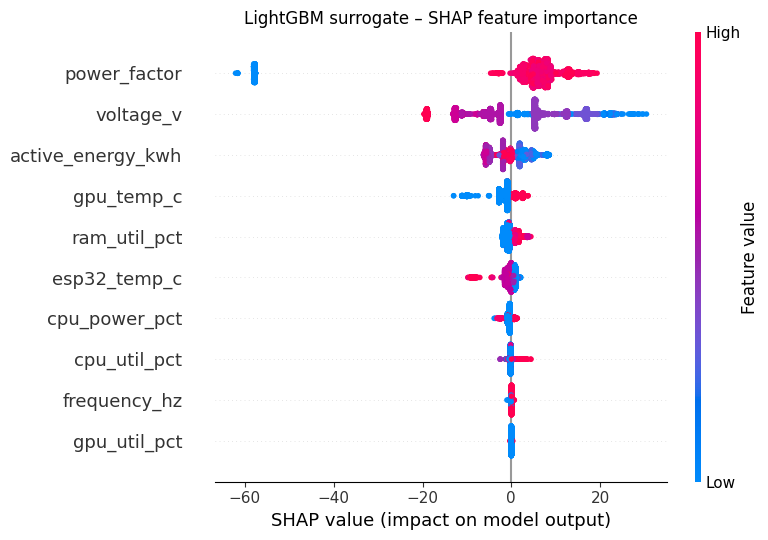

In [5]:
# E-4  –  LightGBM surrogate model  (power_w ← sensors)  ───────────────
import duckdb, pandas as pd, numpy as np
import lightgbm as lgb, shap, joblib
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from pathlib import Path
import matplotlib.pyplot as plt

# ── paths & feature settings ──────────────────────────────────────────
CLEAN  = Path (r"D:/CIM Warwick/Dissertation/Datasets/All Datasets/clean/")
PARQUETS = [
    CLEAN / "workstation_2021_may_aug_tidy.parquet",
    CLEAN / "workstation_2021_aug_dec_tidy.parquet",
]

DROP_COLS = [
    "weekday",
    "current_a",
    "gpu_power_pct",
    "ram_power_pct",
    "cpu_temp_c"   # <- if you take it out
]

TARGET = "power_w"

# ── 1. load & prep dataframe ─────────────────────────────────────────
con = duckdb.connect()
df = con.execute(" UNION ALL ".join(
        [f"SELECT * FROM read_parquet('{p}')" for p in PARQUETS]
     )).fetch_df()

# keep numeric columns, drop flagged
X = df.select_dtypes(include=["float64", "int64"]).drop(columns=DROP_COLS + [TARGET], errors="ignore")
y = df[TARGET]

print(f"Training on {len(X):,} rows, {X.shape[1]} features")

# ── 2. 5-fold CV ------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmses = []

for train_idx, val_idx in kf.split(X):
    dtrain = lgb.Dataset(X.iloc[train_idx], y.iloc[train_idx])
    dval   = lgb.Dataset(X.iloc[val_idx],   y.iloc[val_idx])

    model = lgb.train(
        params=dict(
            objective="regression",
            metric="rmse",
            learning_rate=0.05,
            num_leaves=64,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            bagging_freq=5,
            seed=42,
        ),
        train_set=dtrain,
        valid_sets=[dval],
        num_boost_round=2000,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    pred  = model.predict(X.iloc[val_idx], num_iteration=model.best_iteration)
    mse  = mean_squared_error(y.iloc[val_idx], pred)   # default squared=True
    rmse = np.sqrt(mse)
    rmses.append(rmse)

print("CV RMSEs:", [f"{r:.2f}" for r in rmses])
print(f"Mean CV RMSE: {np.mean(rmses):.2f}")

# ── 3. fit final model on full data -----------------------------------
final_model = lgb.train(
    params=dict(objective="regression", learning_rate=0.05,
                num_leaves=64, feature_fraction=0.8,
                bagging_fraction=0.8, bagging_freq=5, seed=42),
    train_set=lgb.Dataset(X, y),
    num_boost_round=int(np.mean([m.best_iteration for m in [model]]))  # reuse best iters if you like
)

joblib.dump(final_model, "lgbm_surrogate.txt")
print("✓ model saved → lgbm_surrogate.txt")

# ── 4. SHAP summary plot ---------------------------------------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X.sample(5000, random_state=42))   # sample for speed

plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X.sample(5000, random_state=42), show=False)
plt.title("LightGBM surrogate – SHAP feature importance")
plt.tight_layout(); plt.show()


In [6]:
# W-2 ➜ E-4 hyper-parameter tuning  (LightGBM surrogate)
import duckdb, pandas as pd, numpy as np, lightgbm as lgb, joblib, warnings
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)   # quiet LightGBM

# ── 0. paths & feature list (re-use cleaned frame) ───────────────────
FILES   = [CLEAN / "workstation_2021_may_aug_tidy.parquet",
           CLEAN / "workstation_2021_aug_dec_tidy.parquet"]
DROP    = ["weekday", "current_a", "gpu_power_pct",
           "ram_power_pct", "cpu_temp_c"]                 # from W-2
TARGET  = "power_w"

# ── 1. load -----------------------------------------------------------
con = duckdb.connect()
df = con.execute(" UNION ALL ".join([f"SELECT * FROM read_parquet('{p}')" for p in FILES])).fetch_df()
X  = (df.select_dtypes(include=["float64","int64"])
        .drop(columns=DROP + [TARGET], errors="ignore"))
y  = df[TARGET]

print(f"{X.shape[1]} features, {len(X):,} rows")

# ── 2. LightGBM wrapper compatible with RandomizedSearchCV ------------
base = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,      # will be tuned
    random_state=42,
    verbosity=-1
)

param_dist = {
    "num_leaves"        : np.arange(16, 128, 16),
    "learning_rate"     : np.linspace(0.01, 0.2, 20),
    "feature_fraction"  : np.linspace(0.6, 1.0, 5),
    "bagging_fraction"  : np.linspace(0.6, 1.0, 5),
    "bagging_freq"      : [1, 5, 10],
    "min_child_samples" : [10, 25, 50, 100],
    "lambda_l2"         : [0, 0.1, 0.5, 1.0],
    "n_estimators"      : [300, 600, 900, 1200, 1500],
    "max_depth"         : [-1, 4, 6, 8, 10],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# NOTE: older sklearn lacks neg_root_mean_squared_error, so use neg_MSE and sqrt later
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_mean_squared_error",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True,        # retrain on full data with best params
    random_state=42
)

search.fit(X, y)

best_rmse = np.sqrt(-search.best_score_)
print(f"\nBest CV RMSE : {best_rmse:.2f}  (params below)")
print(search.best_params_)

# ── 3. save final model ----------------------------------------------
joblib.dump(search.best_estimator_, "lgbm_surrogate_tuned.txt")
print("✓ tuned model saved → lgbm_surrogate_tuned.txt")


10 features, 4,410,230 rows
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV RMSE : 1.25  (params below)
{'num_leaves': np.int64(80), 'n_estimators': 900, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': np.float64(0.16), 'lambda_l2': 0.1, 'feature_fraction': np.float64(0.8), 'bagging_freq': 10, 'bagging_fraction': np.float64(1.0)}
✓ tuned model saved → lgbm_surrogate_tuned.txt
